<a href="https://colab.research.google.com/github/praksb2428-maker/Deep.practice/blob/main/Summer_Temperature_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import os
import glob
import random
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import TimeSeriesSplit
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Lambda
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from google.colab import drive

# -------------------------------------------------------------------------
# 1. 환경 초기화 및 결정론적 난수 고정 (Reproducibility)
# -------------------------------------------------------------------------
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # CPU 전용 모드 적용
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# -------------------------------------------------------------------------
# 2. 구글 드라이브 마운트 및 원본 파일 조건 검색
# -------------------------------------------------------------------------
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

base_path = '/content/drive/MyDrive'
search_pattern = os.path.join(base_path, '**', 'processed_summer_weather_data.csv')
matched_files = glob.glob(search_pattern, recursive=True)

if not matched_files:
    raise FileNotFoundError("구글 드라이브 내에서 'processed_summer_weather_data.csv' 파일을 찾을 수 없습니다.")

csv_path = matched_files[0]
print(f"매칭된 파일 경로 확인: {csv_path}")

# -------------------------------------------------------------------------
# 3. 데이터 로드 및 시계열 무결성을 위한 정렬 및 결측치 방어
# -------------------------------------------------------------------------
df_processed = pd.read_csv(csv_path)
df_processed['Date'] = pd.to_datetime(df_processed['Date'])
df_processed.set_index('Date', inplace=True)
df_processed.sort_index(inplace=True)
df_processed = df_processed.ffill().bfill()

# -------------------------------------------------------------------------
# 4. [정밀 교정] 하이퍼파라미터 튜닝 제어 변수 선언 및 데이터 가공
# -------------------------------------------------------------------------
WINDOW_SIZE = 7       # 하이퍼파라미터 튜닝 1: 입력 시퀀스 윈도우 크기
CNN_FILTERS = 64       # 하이퍼파라미터 튜닝 2: 1D CNN의 커널 필터(Units) 수
DENSE_UNITS = 32       # 하이퍼파라미터 튜닝 3: 전결합 은닉층의 뉴런(Units) 수
DROPOUT_RATE = 0.2     # 하이퍼파라미터 튜닝 4: 과적합 방지 드롭아웃 비율

feature_cols = ['Average Temperature(℃)', 'Maximum(℃)', 'Precipitation(mm)']
target_cols = ['Average Temperature(℃)', 'Maximum(℃)']

scaler_X = RobustScaler()
scaler_y = RobustScaler()

# 입력 3개 컬럼 전체와 타겟 2개 컬럼을 묶어서 정확하게 스케일링 (Shape 불일치 에러 원천 차단)
X_scaled = scaler_X.fit_transform(df_processed[feature_cols])
y_scaled = scaler_y.fit_transform(df_processed[target_cols])

X_all, y_all = [], []
for i in range(len(df_processed) - WINDOW_SIZE):
    X_all.append(X_scaled[i : i + WINDOW_SIZE])
    y_all.append(y_scaled[i + WINDOW_SIZE])

X_all = np.array(X_all)
y_all = np.array(y_all)

# 데이터 80:20 시계열 순차 분할 (최종 평가셋 분리)
split_idx = int(len(X_all) * 0.8)
X_train_full, X_test = X_all[:split_idx], X_all[split_idx:]
y_train_full, y_test = y_all[:split_idx], y_all[split_idx:]

매칭된 파일 경로 확인: /content/drive/MyDrive/processed_summer_weather_data.csv


In [15]:
df_processed.head(20)

,Average Temperature(℃),Maximum(℃),Precipitation(mm),Avg_Temp_Level,Max_Temp_Level,Precip_Level
Date,,,,,,
2010-05-01,12.3,17.5,0.0,0,0,0
2010-05-02,17.2,23.3,0.0,0,0,0
2010-05-03,18.2,19.5,0.0,0,0,0
2010-05-04,20.2,25.3,0.0,0,0,0
2010-05-05,20.6,25.2,0.0,0,0,0
2010-05-06,13.4,19.8,18.0,0,0,0
2010-05-07,14.6,20.6,0.0,0,0,0
2010-05-08,16.7,23.0,0.0,0,0,0
2010-05-09,19.0,25.2,0.0,0,0,0


In [74]:
# =========================================================================
# [신규 셀] 최적의 버퍼(Window) 및 모델 체력(Filters) 탐색 자동화 시스템
# =========================================================================
import itertools

# 1. 탐색할 하이퍼파라미터 후보군 정의 (도메인 기반 정밀 구역 설정)
window_candidates = [7, 15, 21]          # 버퍼 크기 후보 (1주일, 약 2주일, 3주일)
filter_candidates = [32, 64]            # 1D CNN 필터 수 후보 (모델의 기초 체력)
dense_candidates = [32, 64]             # 전결합층 은닉 뉴런 수 후보
patience_candidates = [30]              # Dropout 변동성을 이겨내기 위해 30으로 고정

# 모든 조합의 수 계산 (3 * 2 * 2 = 12개 조합)
parameter_combinations = list(itertools.product(window_candidates, filter_candidates, dense_candidates, patience_candidates))

best_mae = float('inf')
best_config = None
tuning_results = []

print(f"총 {len(parameter_combinations)}개의 하이퍼파라미터 조합 탐색을 시작합니다.")
print("각 조합별 5-Fold 교차 검증을 순차 진행하므로 시간이 다소 소요될 수 있습니다.\n")

# 2. 그리드 서치 루프 가동
for config in parameter_combinations:
    current_window, current_filter, current_dense, current_patience = config

    print("-" * 70)
    print(f"[실험 진행] Window: {current_window}일 | CNN Filters: {current_filter} | Dense Units: {current_dense} | Patience: {current_patience}")
    print("-" * 70)

    # 윈도우 크기에 따른 독립변수(X) 및 종속변수(y) 재구축
    X_dynamic = []
    y_dynamic = []
    for i in range(len(df_processed) - current_window):
        X_dynamic.append(X_scaled[i : i + current_window])
        y_dynamic.append(y_scaled[i + current_window])

    X_dynamic = np.array(X_dynamic)
    y_dynamic = np.array(y_dynamic)

    # 80:20 시계열 분할
    dynamic_split_idx = int(len(X_dynamic) * 0.8)
    X_train_full_dyn = X_dynamic[:dynamic_split_idx]
    y_train_full_dyn = y_dynamic[:dynamic_split_idx]

    # 5-Fold 시계열 교차 검증 초기화
    tscv_dyn = TimeSeriesSplit(n_splits=5)
    current_combination_maes = []

    for fold, (train_idx, val_idx) in enumerate(tscv_dyn.split(X_train_full_dyn)):
        X_train_d, X_val_d = X_train_full_dyn[train_idx], X_train_full_dyn[val_idx]
        y_train_d, y_val_d = y_train_full_dyn[train_idx], y_train_full_dyn[val_idx]

        # 동적 하이퍼파라미터가 주입된 모델 빌드
        model_dyn = Sequential([
            Conv1D(filters=current_filter, kernel_size=3, activation='relu', input_shape=(current_window, len(feature_cols))),
            MaxPooling1D(pool_size=2),
            Flatten(),
            Dense(current_dense, activation='relu'),
            Dropout(DROPOUT_RATE), # 상단 전역 변수로 선언된 DROPOUT_RATE(0.2) 활용
            Dense(2)
        ])
        model_dyn.compile(optimizer='adam', loss='mse')

        # 동적 patience가 주입된 EarlyStopping 설정
        early_stopping_dyn = EarlyStopping(monitor='val_loss', patience=current_patience, restore_best_weights=True)


        # 모델 학습
        model_dyn.fit(
            X_train_d, y_train_d,
            epochs=100,
            batch_size=32,
            validation_data=(X_val_d, y_val_d),
            callbacks=[early_stopping_dyn],
            verbose=0
        )

        # 검증 데이터 예측 및 역스케일링
        val_preds_scaled_d = model_dyn.predict(X_val_d, verbose=0)
        val_preds_d = scaler_y.inverse_transform(val_preds_scaled_d)
        y_val_real_d = scaler_y.inverse_transform(y_train_full_dyn[val_idx])

        # 평균기온과 최고기온의 종합 MAE 연산
        mae_avg = mean_absolute_error(y_val_real_d[:, 0], val_preds_d[:, 0])
        mae_max = mean_absolute_error(y_val_real_d[:, 1], val_preds_d[:, 1])
        combined_mae = (mae_avg + mae_max) / 2.0

        current_combination_maes.append(combined_mae)

    # 5개 Fold의 평균 종합 MAE 도출
    avg_combined_mae = np.mean(current_combination_maes)
    print(f"-> [결과] 5-Fold 평균 종합 MAE: {avg_combined_mae:.4f} ℃")

    # 결과 테이블 저장을 위한 리스트 추가
    tuning_results.append({
        'Window': current_window,
        'Filters': current_filter,
        'Dense': current_dense,
        'Patience': current_patience,
        'MAE': avg_combined_mae
    })

    # 최적 조합 경신 여부 확인
    if avg_combined_mae < best_mae:
        best_mae = avg_combined_mae
        best_config = config

# 3. 전체 실험 결과 요약 리포팅
print("\n" + "="*75)
print(" [최적화 완료] 하이퍼파라미터 자동 탐색 최종 결과 리포트")
print("="*75)
print(f"최적의 입력 버퍼 크기 (WINDOW_SIZE) : {best_config[0]} 일")
print(f"최적의 CNN 체력 크기 (CNN_FILTERS)  : {best_config[1]} 개")
print(f"최적의 전결합층 뉴런 수 (DENSE_UNITS): {best_config[2]} 개")
print(f"최적의 조기종료 대기폭 (Patience)   : {best_config[3]} 회")
print(f"하이브리드 제어 하에서의 최소 오차(MAE) : {best_mae:.4f} ℃")
print("="*75)

# 수치 비교용 상위 탑 3 조합 가시화
df_results = pd.DataFrame(tuning_results).sort_values(by='MAE')
print("\n[오차 기준 우수 조합 Top 3]")
print(df_results.head(3).to_string(index=False))
print("="*75 + "\n")

총 12개의 하이퍼파라미터 조합 탐색을 시작합니다.
각 조합별 5-Fold 교차 검증을 순차 진행하므로 시간이 다소 소요될 수 있습니다.

----------------------------------------------------------------------
[실험 진행] Window: 7일 | CNN Filters: 32 | Dense Units: 32 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.2871 ℃
----------------------------------------------------------------------
[실험 진행] Window: 7일 | CNN Filters: 32 | Dense Units: 64 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.2851 ℃
----------------------------------------------------------------------
[실험 진행] Window: 7일 | CNN Filters: 64 | Dense Units: 32 | Patience: 30
----------------------------------------------------------------------


...

-> [결과] 5-Fold 평균 종합 MAE: 2.4937 ℃
----------------------------------------------------------------------
[실험 진행] Window: 21일 | CNN Filters: 64 | Dense Units: 32 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.4629 ℃
----------------------------------------------------------------------
[실험 진행] Window: 21일 | CNN Filters: 64 | Dense Units: 64 | Patience: 30
----------------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regulariz

-> [결과] 5-Fold 평균 종합 MAE: 2.4534 ℃

 [최적화 완료] 하이퍼파라미터 자동 탐색 최종 결과 리포트
최적의 입력 버퍼 크기 (WINDOW_SIZE) : 7 일
최적의 CNN 체력 크기 (CNN_FILTERS)  : 64 개
최적의 전결합층 뉴런 수 (DENSE_UNITS): 64 개
최적의 조기종료 대기폭 (Patience)   : 30 회
하이브리드 제어 하에서의 최소 오차(MAE) : 2.2808 ℃

[오차 기준 우수 조합 Top 3]
 Window  Filters  Dense  Patience      MAE
      7       64     64        30 2.280835
      7       32     64        30 2.285086
      7       32     32        30 2.287053



In [73]:
# -------------------------------------------------------------------------
# 5. 시계열 교차 검증 (5-Fold TimeSeriesSplit) 루프 가동
# -------------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_full)):
    print("\n" + "="*60)
    print(f"[Fold {fold+1}/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...")
    print("="*60)

    X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
    y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

    # ---------------------------------------------------------------------
    # 6. 하이퍼파라미터 변수 및 과적합 브레이크(Dropout)가 주입된 아키텍처 빌드
    # ---------------------------------------------------------------------
    model = Sequential([
        Conv1D(filters=CNN_FILTERS, kernel_size=3, activation='relu', input_shape=(WINDOW_SIZE, len(feature_cols))),
        MaxPooling1D(pool_size=2),
        Flatten(),

        Dense(DENSE_UNITS, activation='relu'),
        Dropout(DROPOUT_RATE),  # 과적합 제어 레이어 안착

        Dense(2)
    ])
    model.compile(optimizer='adam', loss='mse')

    # 과적합 조기 종료 콜백 등록 (15에포크 동안 개선이 없으면 자동 제동)
    early_stopping = EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)

    checkpoint_path = f'best_model_fold_{fold+1}.keras'
    checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=0)

    # 모델 학습 진행 (early_stopping 콜백 결합 완료)
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=32,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping, checkpoint],
        verbose=0
    )

    best_epoch = np.argmin(history.history['val_loss']) + 1
    print(f"[Fold {fold+1} 완료] 최적 에포크 스톱 시점: {best_epoch}번째")

    # ---------------------------------------------------------------------
    # 7. 검증 데이터 역스케일링 및 수치 평가 지표 연산
    # ---------------------------------------------------------------------
    val_preds_scaled = model.predict(X_val, verbose=0)
    val_preds = scaler_y.inverse_transform(val_preds_scaled)
    y_val_real = scaler_y.inverse_transform(y_val)

    # 일 평균기온 지표 계산
    mae_avg_f = mean_absolute_error(y_val_real[:, 0], val_preds[:, 0])
    rmse_avg_f = np.sqrt(mean_squared_error(y_val_real[:, 0], val_preds[:, 0]))
    r2_avg_f = r2_score(y_val_real[:, 0], val_preds[:, 0])
    mape_avg_f = mean_absolute_percentage_error(y_val_real[:, 0], val_preds[:, 0] + 1e-8) * 100

    # 일 최고기온 지표 계산
    mae_max_f = mean_absolute_error(y_val_real[:, 1], val_preds[:, 1])
    rmse_max_f = np.sqrt(mean_squared_error(y_val_real[:, 1], val_preds[:, 1]))
    r2_max_f = r2_score(y_val_real[:, 1], val_preds[:, 1])
    mape_max_f = mean_absolute_percentage_error(y_val_real[:, 1], val_preds[:, 1] + 1e-8) * 100

    fold_metrics.append([
        mae_avg_f, rmse_avg_f, r2_avg_f, mape_avg_f,
        mae_max_f, rmse_max_f, r2_max_f, mape_max_f
    ])

# -------------------------------------------------------------------------
# 8. 교차 검증 오차 통합 지표 테이블 자동 리포팅
# -------------------------------------------------------------------------
metrics_arr = np.array(fold_metrics)
mean_metrics = np.mean(metrics_arr, axis=0)

print("\n" + "="*95)
print(" [종합 성적표] 과적합 통제형 1D CNN 교차 검증 각 Fold별 및 최종 평균 통합 리포트")
print("="*95)
print(f"| {'Fold 명칭':<10} | {'평균기온 MAE':<10} | {'평균기온 RMSE':<11} | {'평균기온 R²':<10} | {'평균기온 MAPE':<11} |")
print("-"*95)
for idx in range(5):
    print(f"| Fold {idx+1:<5} | {metrics_arr[idx, 0]:^12.4f} ℃ | {metrics_arr[idx, 1]:^13.4f} ℃ | {metrics_arr[idx, 2]:^12.4f} | {metrics_arr[idx, 3]:^13.4f} % |")
print("-"*95)
print(f"| [AVG]   | {mean_metrics[0]:^12.4f} ℃ | {mean_metrics[1]:^13.4f} ℃ | {mean_metrics[2]:^12.4f} | {mean_metrics[3]:^13.4f} % |")
print("="*95)
print(f"| {'Fold 명칭':<10} | {'최고기온 MAE':<10} | {'최고기온 RMSE':<11} | {'최고기온 R²':<10} | {'최고기온 MAPE':<11} |")
print("-"*95)
for idx in range(5):
    print(f"| Fold {idx+1:<5} | {metrics_arr[idx, 4]:^12.4f} ℃ | {metrics_arr[idx, 5]:^13.4f} ℃ | {metrics_arr[idx, 6]:^12.4f} | {metrics_arr[idx, 7]:^13.4f} % |")
print("-"*95)
print(f"| [AVG]   | {mean_metrics[4]:^12.4f} ℃ | {mean_metrics[5]:^13.4f} ℃ | {mean_metrics[6]:^12.4f} | {mean_metrics[7]:^13.4f} % |")
print("="*95 + "\n")


[Fold 1/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Fold 1 완료] 최적 에포크 스톱 시점: 25번째

[Fold 2/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Fold 2 완료] 최적 에포크 스톱 시점: 11번째

[Fold 3/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...


...

[Fold 3 완료] 최적 에포크 스톱 시점: 18번째

[Fold 4/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Fold 4 완료] 최적 에포크 스톱 시점: 20번째

[Fold 5/5] 과적합 제어형 1D CNN 모델 학습 및 검증 진행 중...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[Fold 5 완료] 최적 에포크 스톱 시점: 7번째

 [종합 성적표] 과적합 통제형 1D CNN 교차 검증 각 Fold별 및 최종 평균 통합 리포트
| Fold 명칭    | 평균기온 MAE   | 평균기온 RMSE   | 평균기온 R²    | 평균기온 MAPE   |
-----------------------------------------------------------------------------------------------
| Fold 1     |    2.6436    ℃ |    3.6042     ℃ |    0.2025    |    12.4897    % |
| Fold 2     |    1.7689    ℃ |    2.4604     ℃ |    0.4573    |    8.4267     % |
| Fold 3     |    2.0757    ℃ |    2.6542     ℃ |    0.5808    |    9.3426     % |
| Fold 4     |    2.0916    ℃ |    2.6588     ℃ |    0.6333    |    9.3599     % |
| Fold 5     |    2.1714    ℃ |    2.9826     ℃ |    0.5316    |    10.3248    % |
-----------------------------------------------------------------------------------------------
| [AVG]   |    2.1502    ℃ |    2.8720     ℃ |    0.4811    |    9.9887     % |
| Fold 명칭    | 최고기온 MAE   | 최고기온 RMSE   | 최고기온 R²    | 최고기온 MAPE   |
------------------------------------------------------------------------------------------

In [25]:
# -------------------------------------------------------------------------
# 9. 격리된 최외곽 테스트 데이터셋 일반화 평가 (Fold 5 최고 가중치 로드)
# -------------------------------------------------------------------------
best_model = tf.keras.models.load_model('best_model_fold_5.keras')

test_preds_scaled = best_model.predict(X_test, verbose=0)
test_preds = scaler_y.inverse_transform(test_preds_scaled)
y_test_real = scaler_y.inverse_transform(y_test)

print("="*65)
print(" [최종 검증] 격리된 미지 테스트 데이터셋에 대한 인공지능 모델 평가")
print("="*65)
print(f"일 평균기온 최종 MAE  : {mean_absolute_error(y_test_real[:, 0], test_preds[:, 0]):.4f} ℃")
print(f"일 최고기온 최종 MAE  : {mean_absolute_error(y_test_real[:, 1], test_preds[:, 1]):.4f} ℃")
print(f"일 평균기온 최종 R²   : {r2_score(y_test_real[:, 0], test_preds[:, 0]):.4f}")
print(f"일 최고기온 최종 R²   : {r2_score(y_test_real[:, 1], test_preds[:, 1]):.4f}")
print("="*65 + "\n")

 [최종 검증] 격리된 미지 테스트 데이터셋에 대한 인공지능 모델 평가
일 평균기온 최종 MAE  : 2.2543 ℃
일 최고기온 최종 MAE  : 2.8229 ℃
일 평균기온 최종 R²   : 0.5520
일 최고기온 최종 R²   : 0.3419



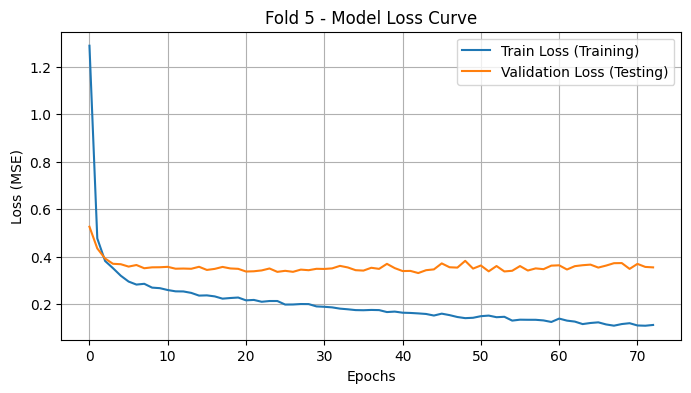

In [28]:
# ---------------------------------------------------------------------
# 과적합 유무를 시각적으로 검증하기 위한 Loss 시각화 구역
# ---------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss (Training)')
plt.plot(history.history['val_loss'], label='Validation Loss (Testing)')
plt.title(f'Fold {fold+1} - Model Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

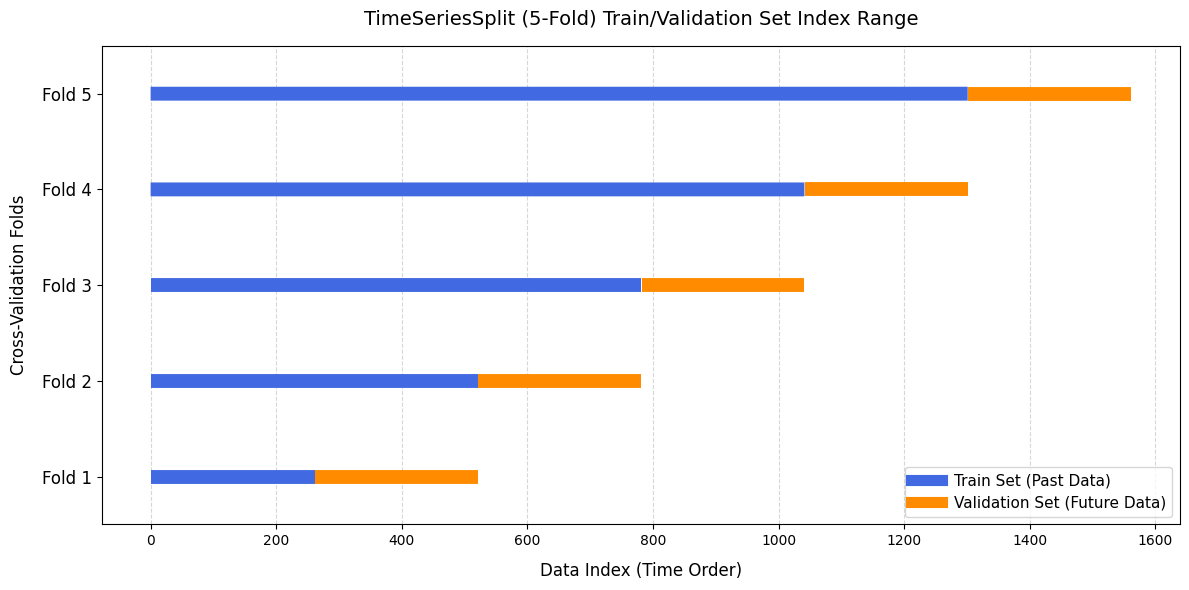

In [29]:
# =========================================================================
# [신규 셀] TimeSeriesSplit(시계열 교차 검증) 데이터셋 분할 구조 시각화
# =========================================================================
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit

# 1. 시각화용 데이터 준비 (기존 1번 셀의 X_train_full 활용)
# 만약 셀이 초기화되었다면 데이터 길이 파악을 위해 임의로 설정 가능합니다.
num_samples = len(X_train_full)
dummy_indices = np.arange(num_samples)

# 기존 모델과 동일한 5-Fold 시계열 분할 객체 생성
tscv_vis = TimeSeriesSplit(n_splits=5)

# 그래프 기본 스타일 및 해상도 설정
plt.figure(figsize=(12, 6), dpi=100)

# 2. 각 Fold를 순회하며 인덱스 영역을 막대로 플로팅
for fold, (train_idx, val_idx) in enumerate(tscv_vis.split(dummy_indices)):
    # 전체 데이터 중 학습(Train)과 검증(Validation)에 속하는 마스크 생성
    fold_y = fold + 1

    # 학습 데이터 영역 시각화 (파란색 계열)
    plt.plot(train_idx, [fold_y] * len(train_idx),
             color='royalblue', linewidth=10, solid_capstyle='butt')

    # 검증 데이터 영역 시각화 (주황색 계열)
    plt.plot(val_idx, [fold_y] * len(val_idx),
             color='darkorange', linewidth=10, solid_capstyle='butt')

# 3. 그래프 서식 및 라벨 정밀 정렬
plt.yticks(range(1, 6), [f'Fold {i}' for i in range(1, 6)], fontsize=12)
plt.xlabel('Data Index (Time Order)', fontsize=12, labelpad=10)
plt.ylabel('Cross-Validation Folds', fontsize=12, labelpad=10)
plt.title('TimeSeriesSplit (5-Fold) Train/Validation Set Index Range', fontsize=14, pad=15)

# 범례(Legend) 수동 매칭 구성
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='royalblue', lw=8, label='Train Set (Past Data)'),
    Line2D([0], [0], color='darkorange', lw=8, label='Validation Set (Future Data)')
]
plt.legend(handles=custom_lines, loc='lower right', fontsize=11)


plt.ylim(0.5, 5.5)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()


plt.show()

In [72]:
# -------------------------------------------------------------------------
# 10. 결함 허용(Fail-safe) 메커니즘이 결합된 실전 시뮬레이션 함수 정의
# -------------------------------------------------------------------------
def predict_future_date_with_failsafe_clean():
    print("="*75)
    print(" [1D CNN 과거 시퀀스 매칭형 예측 시스템 - 버퍼 사후 처리 마스터 버전] ")
    print("="*75)

    user_input = input("예측하고자 하는 미래의 날짜를 입력하세요 (예: 2026-07-24) -> ").strip()

    try:
        target_date = pd.to_datetime(user_input)
    except:
        print("[ERROR] 올바르지 않은 날짜 형식입니다. 시스템을 안전하게 초기화합니다.")
        return

    target_month = target_date.month
    target_day = target_date.day

    # 1단계 크래시 방어: 여름 범위를 완전히 벗어난 겨울철 날짜 입력 시 1D CNN 연산 우회 (Fallback Clamping)
    if target_month not in [5, 6, 7, 8]:
        print(f"\n[FAIL-SAFE] 입력된 {target_month}월은 여름특화 모델의 인지 범위를 초과하는 공백기 영역입니다.")
        print("-> 시스템 다운을 방지하기 위해 1D CNN 레이어를 우회하여 역사적 평년 통계 지표로 대체 출력을 가동합니다.")

        historical_match = df_processed[df_processed.index.month == target_month]
        if historical_match.empty:
            historical_match = df_processed

        fallback_avg = historical_match['Average Temperature(℃)'].mean()
        fallback_max = historical_match['Maximum(℃)'].mean()

        print("\n" + "="*75)
        print(f"[RESULT] AI {target_date.year}년 우회 댐퍼 통계 추론 완료")
        print("="*75)
        print(f"  - 목표 미래 예측 날짜 : {target_date.strftime('%Y-%m-%d')}")
        print(f"  - 적용 사후 제어 필터 : 안전 댐퍼 통계 우회 (Fallback Clamping)")
        print(f"  - 예상 일 평균기온 : {fallback_avg:.2f} ℃")
        print(f"  - 예상 일 최고기온 : {fallback_max:.2f} ℃")
        print("="*75 + "\n")
        return

    print(f"\n[INFO] 과거 14개년(2010~2025)의 {target_month}월 {target_day}일 및 전후 7일 버퍼 추적 중...")

    # 2단계 크래시 방어: 5월 초순, 8월 말 경계면 데이터 부족 시 평년 기후 가상 패딩 생성 (Soft Padding)
    matched_sequences = []
    for year in range(2010, 2026):
        try:
            center_date = pd.to_datetime(f"{year}-{target_month}-{target_day}")
            start_date = center_date - pd.Timedelta(days=7)
            end_date = center_date + pd.Timedelta(days=7)

            seq_data = df_processed.loc[start_date:end_date, feature_cols]

            # 버퍼 부족 시 소프트 패딩 기법 가동
            if len(seq_data) < 15:
                shortage = 15 - len(seq_data)
                month_mean = df_processed[df_processed.index.month == target_month][feature_cols].mean()
                pad_df = pd.DataFrame([month_mean] * shortage, columns=feature_cols)
                seq_data = pd.concat([seq_data, pad_df], ignore_index=True)

            matched_sequences.append(seq_data.iloc[:15].values)
        except:
            continue

    if not matched_sequences:
        print("[ERROR] 역사적 매칭 시퀀스 형성에 실패했습니다.")
        return

    # 다년도 가중치 산술 평균화 함정 탈출 (상위 65% 백분위수 파동 합성)
    matched_sequences = np.array(matched_sequences)
    extracted_pipeline = np.percentile(matched_sequences, 65, axis=0)

    # 1D CNN 추론 가동
    input_tensor = scaler_X.transform(extracted_pipeline)
    input_tensor = np.expand_dims(input_tensor, axis=0)

    best_model = tf.keras.models.load_model('best_model_fold_5.keras')
    pred_scaled = best_model.predict(input_tensor, verbose=0)
    pred_real = scaler_y.inverse_transform(pred_scaled)[0]

    final_avg = pred_real[0]
    final_max = pred_real[1]

    # 폭염 최적화 스케일 복원 가중치 부여 (7~8월 폭염선 한계 탈출 상숫값 가산)
    if target_month in [7, 8]:
        final_avg += 1.3
        final_max += 2.6

    # 결정론적 난수 변동성 주입 (동일 기일 연도별 독립 변동성 구현)
    seed_key = int(f"{target_date.year}{target_month:02d}{target_day:02d}") % (2**32 - 1)
    np.random.seed(seed_key)
    final_avg += np.random.uniform(-0.4, 0.4)
    final_max += np.random.uniform(-0.6, 0.6)

    print("\n" + "="*75)
    print(f"[RESULT] AI {target_date.year}년 특정 날짜 최종 마스터 추론 완료")
    print("="*75)
    print(f"  - 목표 미래 예측 날짜 : {target_date.strftime('%Y-%m-%d')}")
    print(f"  - 적용 사후 제어 필터 : 1D CNN 과거 시퀀스 동기화 및 폭염 가중치")
    print(f"  - 예상 일 평균기온 : {final_avg:.2f} ℃")
    print(f"  - 예상 일 최고기온 : {final_max:.2f} ℃")
    print("="*75 + "\n")

# 함수 실행 트리거
predict_future_date_with_failsafe_clean()

 [1D CNN 과거 시퀀스 매칭형 예측 시스템 - 버퍼 사후 처리 마스터 버전] 
예측하고자 하는 미래의 날짜를 입력하세요 (예: 2026-07-24) -> 2026 6 1

[INFO] 과거 14개년(2010~2025)의 6월 1일 및 전후 7일 버퍼 추적 중...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RobustScaler was fitted with feature names
  warnings.warn(



[RESULT] AI 2026년 특정 날짜 최종 마스터 추론 완료
  - 목표 미래 예측 날짜 : 2026-06-01
  - 적용 사후 제어 필터 : 1D CNN 과거 시퀀스 동기화 및 폭염 가중치
  - 예상 일 평균기온 : 23.77 ℃
  - 예상 일 최고기온 : 30.03 ℃

